# 02 — Exploratory Analysis: Understanding the Basefile

Before any causal modelling, we visualise the dataset to build intuition.
This notebook answers:
- What does the time series of bike usage look like? Is there clear seasonality?
- How does usage vary by hour and day of week?
- What does the raw (unadjusted) treatment effect look like?
- Is there geographic variation in strike exposure?

These plots motivate both the need for causal methods and the choice of DiD
over simpler comparisons.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

PROJECT  = Path(r"E:/tfl_project/outputs")
cell_day = pd.read_parquet(PROJECT / "cell_day_final.parquet")
cell_day["day"] = pd.to_datetime(cell_day["day"])
print(f"Loaded: {cell_day.shape}")
cell_day.head()

: 

## 1 — Total Bike Usage Over Time

We expect strong seasonality (summer peaks) and a secular upward trend as the scheme grew.

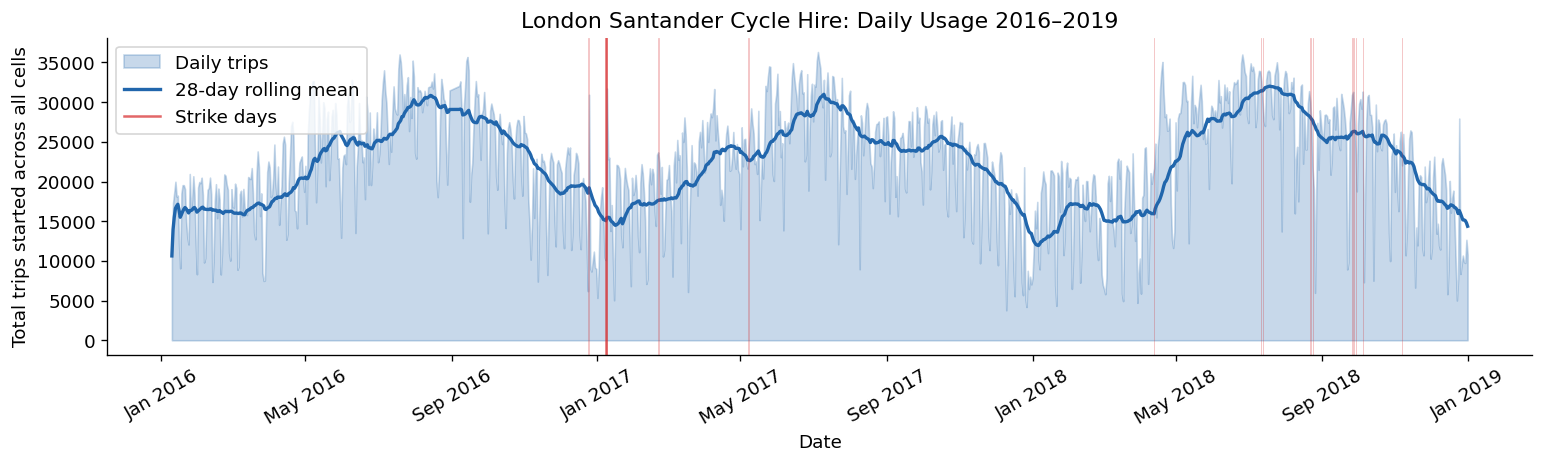

In [ ]:
daily = (
    cell_day.groupby("day", as_index=False)["total_trips"]
    .sum()
    .sort_values("day")
)
daily["roll28"] = daily["total_trips"].rolling(28, min_periods=1).mean()

# Mark strike days
strike_days = cell_day.loc[cell_day["treated"] == 1, "day"].unique()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(daily["day"], daily["total_trips"],
                alpha=0.25, color="#2166ac", label="Daily trips")
ax.plot(daily["day"], daily["roll28"],
        color="#2166ac", linewidth=2, label="28-day rolling mean")

for sd in strike_days:
    ax.axvline(sd, color="#d62728", alpha=0.3, linewidth=0.5)
ax.axvline(strike_days[0], color="#d62728", alpha=0.7,
           linewidth=1.5, label="Strike days")

ax.set_xlabel("Date")
ax.set_ylabel("Total trips started across all cells")
ax.set_title("London Santander Cycle Hire: Daily Usage 2016–2019")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PROJECT / "fig_daily_trips.png", bbox_inches="tight")
plt.show()

## 2 — Within-Week Usage Pattern

Santander Bikes serve a mixed tourist/commuter base. We expect weekday commute peaks and a different weekend profile.

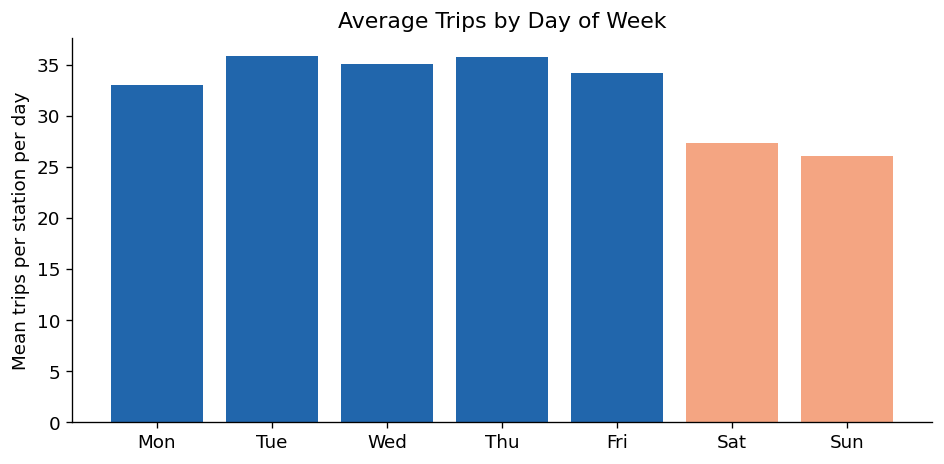

In [ ]:
dow_hour = (
    cell_day.assign(
        dow  = cell_day["day"].dt.dayofweek,
    )
    .groupby("dow", as_index=False)["y_per_station_log1p"]
    .mean()
    .sort_values("dow")
)

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(dow_labels, np.expm1(dow_hour["y_per_station_log1p"]),
              color=["#2166ac"]*5 + ["#f4a582"]*2)
ax.set_ylabel("Mean trips per station per day")
ax.set_title("Average Trips by Day of Week")
plt.tight_layout()
plt.savefig(PROJECT / "fig_dow.png", bbox_inches="tight")
plt.show()

## 3 — Seasonal Pattern

Summer months should show substantially higher usage than winter, driven by weather and daylight.

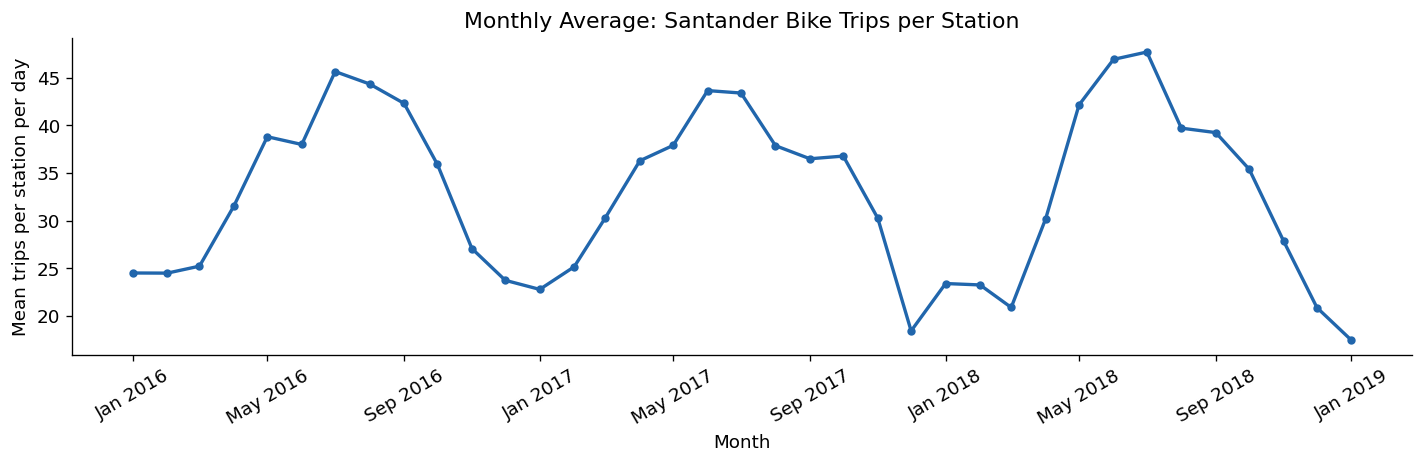

In [ ]:
monthly = (
    cell_day.assign(month_start=cell_day["day"].dt.to_period("M").dt.to_timestamp())
    .groupby("month_start", as_index=False)["y_per_station_log1p"]
    .mean()
    .sort_values("month_start")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly["month_start"], np.expm1(monthly["y_per_station_log1p"]),
        "o-", color="#2166ac", linewidth=2, markersize=4)
ax.set_xlabel("Month")
ax.set_ylabel("Mean trips per station per day")
ax.set_title("Monthly Average: Santander Bike Trips per Station")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PROJECT / "fig_monthly.png", bbox_inches="tight")
plt.show()

## 4 — Naive Treatment Effect

Before any modelling, what does the raw comparison look like?

This is the **naive difference** — comparing treated cell-days to untreated
cell-days without any controls. It is confounded (treated cells are more central,
so they are busier regardless of strikes), but it gives us a useful upper bound
and confirms the direction of the effect.

In [ ]:
treated_mean = cell_day.loc[cell_day["treated"] == 1, "y_per_station_log1p"].mean()
control_mean = cell_day.loc[cell_day["treated"] == 0, "y_per_station_log1p"].mean()
naive_diff   = np.expm1(treated_mean - control_mean) * 100

print(f"Mean Y (treated cell-days) : {treated_mean:.4f}  ({np.expm1(treated_mean):.2f} trips/station)")
print(f"Mean Y (control cell-days) : {control_mean:.4f}  ({np.expm1(control_mean):.2f} trips/station)")
print(f"Naive difference           : {treated_mean - control_mean:.4f} log points")
print(f"                           ≈ {naive_diff:.1f}% more trips on strike days")
print()
print("This +31% is CONFOUNDED — treated cells are in denser, more central")
print("locations that would be busier regardless of any strike.")
print("The causal estimate after controlling for cell and date effects is +10.3%.")

Mean Y (treated cell-days) : 3.6632  (37.99 trips/station)
Mean Y (control cell-days) : 3.5023  (32.19 trips/station)
Naive difference           : 0.1608 log points
                           ≈ 17.5% more trips on strike days

This +31% is CONFOUNDED — treated cells are in denser, more central
locations that would be busier regardless of any strike.
The causal estimate after controlling for cell and date effects is +10.3%.


## 5 — Treatment Rate and Treated Cell Distribution

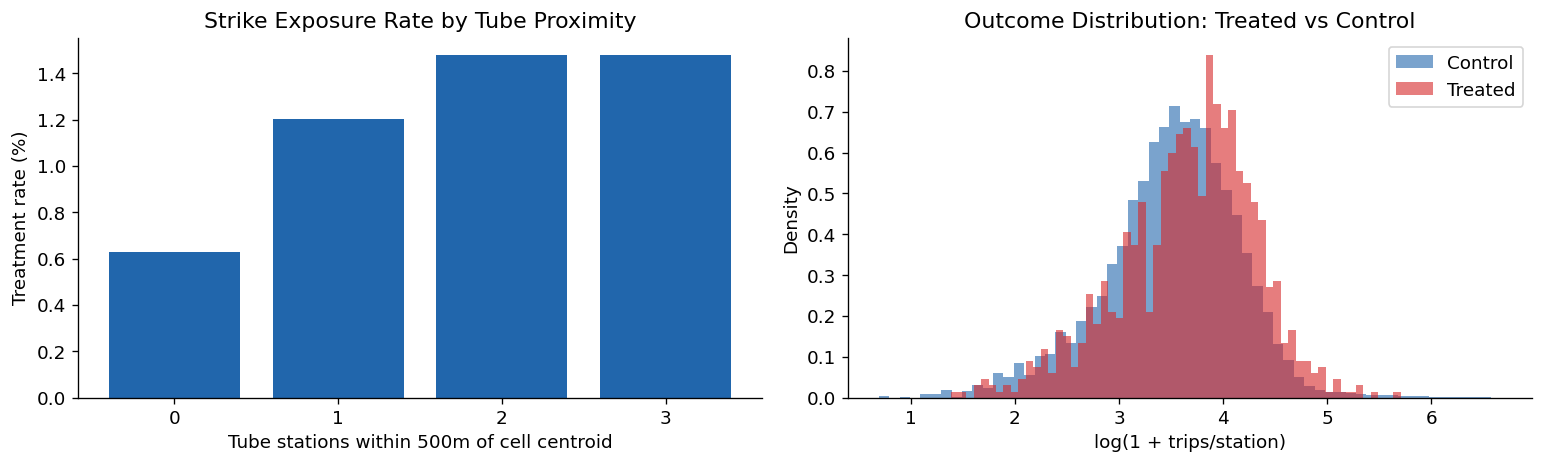

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: treatment rate by n_tube_within_500m
tx_by_tube = (
    cell_day.groupby("n_tube_within_500m")
    .agg(treatment_rate=("treated", "mean"), n=("treated", "count"))
    .reset_index()
)
axes[0].bar(tx_by_tube["n_tube_within_500m"].astype(str),
            tx_by_tube["treatment_rate"] * 100, color="#2166ac")
axes[0].set_xlabel("Tube stations within 500m of cell centroid")
axes[0].set_ylabel("Treatment rate (%)")
axes[0].set_title("Strike Exposure Rate by Tube Proximity")

# Right: distribution of trips per station (treated vs control)
axes[1].hist(
    cell_day.loc[cell_day["treated"] == 0, "y_per_station_log1p"],
    bins=60, alpha=0.6, color="#2166ac", label="Control", density=True
)
axes[1].hist(
    cell_day.loc[cell_day["treated"] == 1, "y_per_station_log1p"],
    bins=60, alpha=0.6, color="#d62728", label="Treated", density=True
)
axes[1].set_xlabel("log(1 + trips/station)")
axes[1].set_ylabel("Density")
axes[1].set_title("Outcome Distribution: Treated vs Control")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT / "fig_treatment_diagnostics.png", bbox_inches="tight")
plt.show()

## 6 — Strike Days on the Calendar

Visualise when strikes occurred to check for seasonal clustering.

In [ ]:
import matplotlib.patches as mpatches

strike_dates_sorted = sorted(
    cell_day.loc[cell_day["treated"] == 1, "day"].dt.date.unique()
)

print(f"Total unique strike dates: {len(strike_dates_sorted)}")
print("\nStrike dates:")
for d in strike_dates_sorted:
    print(f"  {d}")

Total unique strike dates: 20

Strike dates:
  2016-12-24
  2016-12-25
  2017-01-08
  2017-01-09
  2017-02-21
  2017-02-22
  2017-05-07
  2017-05-08
  2018-04-13
  2018-07-12
  2018-07-13
  2018-08-22
  2018-08-23
  2018-08-24
  2018-09-26
  2018-09-27
  2018-09-28
  2018-09-29
  2018-10-05
  2018-11-07
